# 3-Pulse Mach-Zehnder Interferometer

Demonstrates a $\pi/2 - \pi - \pi/2$ Mach-Zehnder atom interferometer sequence.

Pulse phases: $0$, $\phi$, $4\phi$ respectively, with $\phi$ scanned from $0$ to $2\pi$.

Repeat with detunings drawn from a distribution based on a Maxwell-Boltzmann distribution of velocities at $T = 100 nK$.


In [1]:
import sys

p = "2026-03-02 LMT sim"
if not any(p in s for s in sys.path):
    sys.path.append(p)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import version_info as vs

from lmt_simulation import (
    make_atom_states,
    transform_state_vector,
    propagate_states_in_borde_representation,
    pulse_interaction_in_borde_representation,
    calculate_ground_and_excited_probabilities,
    K_WAVEVECTOR,
    TRANSITION_FREQUENCY,
)

%matplotlib inline

In [3]:
from scipy import constants

# np.random.seed(42)

T_FREE = 200e-6  # Free evolution time between pulses
# T_FREE = 0

# Realistic rabi freq
T_PI = 45e-6
RABI_FREQ = 1 / (T_PI * 2)
MASS_ATOM = constants.atomic_mass * 87
TRANSITION_WAVELENGTH = 698e-9
# Single-photon recoil frequency: f_r = h / (2 * m * lambda^2)
F_RECOIL = constants.h / (MASS_ATOM * TRANSITION_WAVELENGTH**2)

# Draw velocities from 1D Maxwell-Boltzmann distribution at T
# 1D MB is a Gaussian with sigma_v = sqrt(k_B T / m)
N_ATOMS = 200
TEMPERATURE = 200e-9

In [4]:
sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
velocities = np.random.normal(0, sigma_v, size=N_ATOMS)
phi_values = np.linspace(0, 2 * np.pi, 101)

In [5]:
from tqdm import tqdm


def calc_mz_excitation_borde(
    phi,
    detuning_hz,
    initial_velocity_z=0.0,
    time_between_pulses=T_FREE,
):
    m_values, positions, velocities, internal_amplitude, internal_is_ground = make_atom_states(
        initial_velocity_z=initial_velocity_z,
        c0=1,
        c1=0,
    )

    omega_laser = 2 * np.pi * (TRANSITION_FREQUENCY + detuning_hz)
    current_time = 0.0

    squiggly_amplitudes = transform_state_vector(
        m_values,
        internal_amplitude,
        internal_is_ground,
        omega_laser=omega_laser,
        t=current_time,
        z=0.0,
        vz=initial_velocity_z,
        inverse=False,
    )

    # First pi/2 pulse, phase 0
    m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
        pulse_interaction_in_borde_representation(
            m_values,
            squiggly_amplitudes,
            internal_is_ground,
            positions,
            velocities,
            pulse_detuning=detuning_hz,
            t_pulse=T_PI / 2,
            pulse_rabi_freq=RABI_FREQ,
            pulse_phase=0.0,
            k_sign=+1,
            k_wavevector=K_WAVEVECTOR,
            vz=initial_velocity_z,
        )
    )
    current_time += T_PI / 2

    if time_between_pulses > 0:
        m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
            propagate_states_in_borde_representation(
                m_values,
                squiggly_amplitudes,
                internal_is_ground,
                positions,
                velocities,
                time_of_propegation=time_between_pulses,
                omega_laser=omega_laser,
                vz=initial_velocity_z,
                k_sign=+1,
                k_wavevector=K_WAVEVECTOR,
            )
        )
        current_time += time_between_pulses

    m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
        pulse_interaction_in_borde_representation(
            m_values,
            squiggly_amplitudes,
            internal_is_ground,
            positions,
            velocities,
            pulse_detuning=detuning_hz,
            t_pulse=T_PI,
            pulse_rabi_freq=RABI_FREQ,
            pulse_phase=phi,
            k_sign=+1,
            k_wavevector=K_WAVEVECTOR,
            vz=initial_velocity_z,
        )
    )
    current_time += T_PI

    if time_between_pulses > 0:
        m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
            propagate_states_in_borde_representation(
                m_values,
                squiggly_amplitudes,
                internal_is_ground,
                positions,
                velocities,
                time_of_propegation=time_between_pulses,
                omega_laser=omega_laser,
                vz=initial_velocity_z,
                k_sign=+1,
                k_wavevector=K_WAVEVECTOR,
            )
        )
        current_time += time_between_pulses

    m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = (
        pulse_interaction_in_borde_representation(
            m_values,
            squiggly_amplitudes,
            internal_is_ground,
            positions,
            velocities,
            pulse_detuning=detuning_hz,
            t_pulse=T_PI / 2,
            pulse_rabi_freq=RABI_FREQ,
            pulse_phase=4 * phi,
            k_sign=+1,
            k_wavevector=K_WAVEVECTOR,
            vz=initial_velocity_z,
        )
    )
    current_time += T_PI / 2

    internal_amplitude_final = transform_state_vector(
        m_values,
        squiggly_amplitudes,
        internal_is_ground,
        omega_laser=omega_laser,
        t=current_time,
        z=0.0,
        vz=initial_velocity_z,
        inverse=True,
    )

    ground_prob, excited_prob = calculate_ground_and_excited_probabilities(
        m_values,
        internal_amplitude_final,
        internal_is_ground,
    )

    total_prob = ground_prob + excited_prob
    return excited_prob / total_prob


# Simulate for each atom velocity
excitation_curves = np.empty((N_ATOMS, len(phi_values)))

for ind_atom, velocity in enumerate(tqdm(velocities, desc="Simulating atoms")):
    excitation_fractions = np.empty_like(phi_values)

    for ind_phi, phi in enumerate(phi_values):
        excitation_fractions[ind_phi] = calc_mz_excitation_borde(
            phi,
            detuning_hz=F_RECOIL/2,
            initial_velocity_z=velocity,
            time_between_pulses=T_FREE,
        )

        if excitation_fractions[ind_phi] < 0 or excitation_fractions[ind_phi] > 1:
            print(
                f"Warning: Unphysical excitation fraction {excitation_fractions[ind_phi]:.3f} "
                f"for velocity {velocity:.2f} m/s, phi={phi:.2f}"
            )

    excitation_curves[ind_atom, :] = excitation_fractions

mean_excitation = np.mean(excitation_curves, axis=0)
std_excitation = np.std(excitation_curves, axis=0)

Simulating atoms:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating atoms:   1%|          | 2/200 [00:00<00:10, 19.27it/s]

Simulating atoms:   2%|▏         | 4/200 [00:00<00:10, 19.29it/s]

Simulating atoms:   3%|▎         | 6/200 [00:00<00:10, 18.81it/s]

Simulating atoms:   4%|▍         | 8/200 [00:00<00:10, 17.86it/s]

...

Simulating atoms:  97%|█████████▋| 194/200 [00:10<00:00, 18.43it/s]

Simulating atoms:  98%|█████████▊| 196/200 [00:10<00:00, 18.59it/s]

Simulating atoms:  99%|█████████▉| 198/200 [00:10<00:00, 18.53it/s]

Simulating atoms: 100%|██████████| 200/200 [00:10<00:00, 18.56it/s]

Simulating atoms: 100%|██████████| 200/200 [00:10<00:00, 18.28it/s]

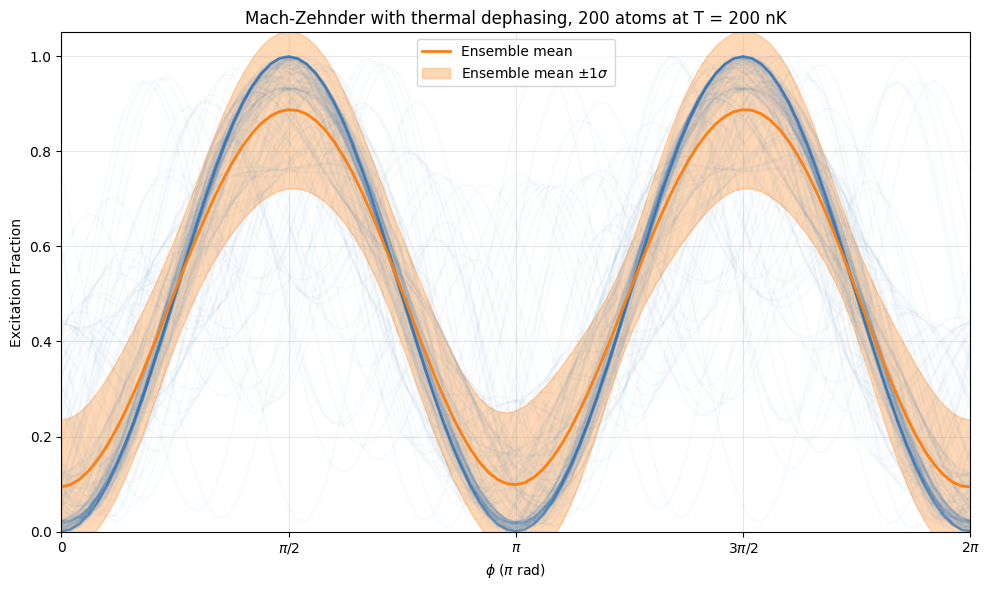

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot individual traces with low alpha
for curve in excitation_curves:
    ax.plot(phi_values / np.pi, curve, color="tab:blue", alpha=0.03)

# Plot mean and std
ax.plot(
    phi_values / np.pi,
    mean_excitation,
    color="tab:orange",
    lw=2,
    label="Ensemble mean",
)
ax.fill_between(
    phi_values / np.pi,
    mean_excitation - std_excitation,
    mean_excitation + std_excitation,
    color="tab:orange",
    alpha=0.3,
    label=r"Ensemble mean $\pm 1\sigma$",
)

ax.set_xlabel(r"$\phi$ ($\pi$ rad)")
ax.set_ylabel("Excitation Fraction")
ax.set_title(
    f"Mach-Zehnder with thermal dephasing, {N_ATOMS} atoms at T = {TEMPERATURE*1e9:.0f} nK"
)
ax.set_xticks([0, 0.5, 1, 1.5, 2], ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.05)
vs.tag_plot(small=True)
fig.tight_layout()